### Credit Scorecard Development

#### Objective

Transform the Probability of Default (PD) model into an interpretable credit scorecard by converting model outputs into risk scores.

The scorecard enables:

- Credit decisioning
- Risk ranking
- Approval strategy design
- Portfolio segmentation
- Underwriting support

This notebook develops score scaling, score distribution analysis, risk bands, and approval cut-off strategies.

In [7]:
import pandas as pd
import numpy as np
import pickle

import statsmodels.api as sm

In [8]:
with open("../Models/final_logit.pkl", "rb") as f:
    final_model = pickle.load(f)

with open("../Models/final_features.pkl", "rb") as f:
    final_features = pickle.load(f)

with open("../Models/woe_bins.pkl", "rb") as f:
    bins = pickle.load(f)

In [9]:
train_model = pd.read_csv(
    "../Dataset/processed/train_model.csv"
)

test_model = pd.read_csv(
    "../Dataset/processed/test_model.csv"
)

In [10]:
X_test = sm.add_constant(
    test_model[final_features]
)

test_model['PD'] = final_model.predict(X_test)

In [11]:
test_model['PD'].describe()

count    87493.000000
mean         0.030151
std          0.027690
min          0.001332
25%          0.013545
50%          0.023506
75%          0.037933
max          0.318006
Name: PD, dtype: float64

### Calculation of Factor & Offset

In [12]:
BASE_SCORE = 600
PDO = 20
BASE_ODDS = 50

In [13]:
factor = PDO / np.log(2)

offset = (
    BASE_SCORE
    - factor*np.log(BASE_ODDS)
)

print("Factor:", factor)
print("Offset:", offset)

Factor: 28.85390081777927
Offset: 487.1228762045055


In [14]:
# PD -> Odds
test_model['odds'] = (
    (1 - test_model['PD'])
    /
    test_model['PD']
)

In [15]:
# Odds -> Score
test_model['score'] = (

    offset

    +

    factor*np.log(
        test_model['odds']
    )

)

In [16]:
test_model[['PD','score']].head()

,PD,score
0,0.058497,567.293344
1,0.020679,598.434074
2,0.028291,589.165021
3,0.045000,575.272872
4,0.017605,603.167560


In [17]:
test_model['score'].describe()

count    87493.000000
mean       595.871521
std         23.165931
min        509.136987
25%        580.415296
50%        594.652858
75%        610.850385
max        678.138020
Name: score, dtype: float64

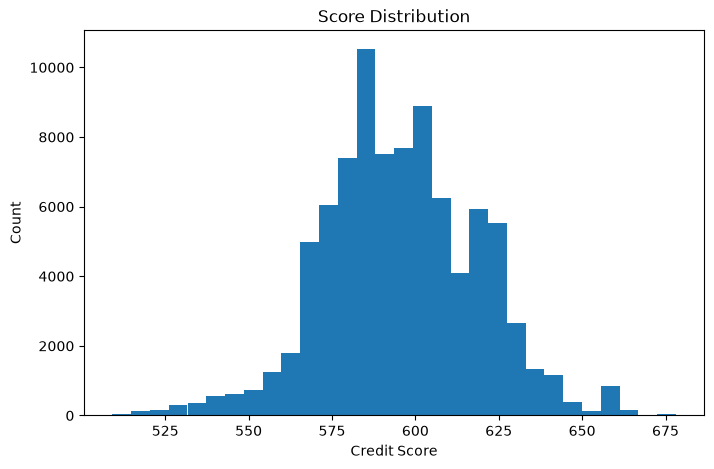

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(
    test_model['score'],
    bins=30
)

plt.xlabel("Credit Score")

plt.ylabel("Count")

plt.title("Score Distribution")

plt.show()

In [19]:
test_model['risk_band'] = pd.qcut(

    test_model['score'],

    q=10,

    labels=[
        'RB1','RB2','RB3','RB4','RB5',
        'RB6','RB7','RB8','RB9','RB10'
    ]

)

In [20]:
band_perf = (

    test_model

    .groupby('risk_band')

    .agg(

        accounts=('TARGET','count'),

        bad_rate=('TARGET','mean'),

        avg_score=('score','mean'),

        avg_pd=('PD','mean')

    )

)

band_perf

,accounts,bad_rate,avg_score,avg_pd
risk_band,,,,
RB1,8750,0.091200,556.081803,0.090867
RB2,8795,0.045139,573.465263,0.047940
RB3,9733,0.036577,580.768417,0.037606
RB4,7752,0.030186,586.276933,0.031199
RB5,9466,0.027361,591.852309,0.025897
RB6,8640,0.021296,598.413839,0.020748
RB7,8300,0.015060,604.555880,0.016812
RB8,8768,0.014484,611.458184,0.013341
RB9,9495,0.007583,622.199709,0.009199


In [21]:
score_bins = [
    0,
    560,
    580,
    600,
    620,
    900
]

score_labels = [
    'E',
    'D',
    'C',
    'B',
    'A'
]

test_model['grade'] = pd.cut(
    test_model['score'],
    bins=score_bins,
    labels=score_labels
)

In [22]:
test_model[['score','grade']].head()

,score,grade
0,567.293344,D
1,598.434074,C
2,589.165021,C
3,575.272872,D
4,603.167560,B


### Approval Strategy

In [23]:
pd.qcut(
    test_model['score'],
    q=10
).value_counts().sort_index()

score
(509.136, 568.398]    8750
(568.398, 576.771]    8795
(576.771, 584.037]    9733
(584.037, 588.336]    7752
(588.336, 594.653]    9466
(594.653, 602.043]    8640
(602.043, 607.171]    8300
(607.171, 618.072]    8768
(618.072, 625.205]    9495
(625.205, 678.138]    7794
Name: count, dtype: int64

In [24]:
band_perf = (

    test_model

    .groupby(
        pd.qcut(
            test_model['score'],
            q=10
        )
    )

    ['TARGET']

    .mean()
)

band_perf

score
(509.136, 568.398]    0.091200
(568.398, 576.771]    0.045139
(576.771, 584.037]    0.036577
(584.037, 588.336]    0.030186
(588.336, 594.653]    0.027361
(594.653, 602.043]    0.021296
(602.043, 607.171]    0.015060
(607.171, 618.072]    0.014484
(618.072, 625.205]    0.007583
(625.205, 678.138]    0.010393
Name: TARGET, dtype: float64

In [25]:
test_model['grade'] = pd.cut(
    test_model['score'],
    bins=[
        0,
        580,
        600,
        620,
        900
    ],
    labels=[
        'D',
        'C',
        'B',
        'A'
    ]
)

grade_summary = (

    test_model

    .groupby('grade')

    .agg(

        total_accounts=('TARGET', 'count'),

        bad_accounts=('TARGET', 'sum'),

        bad_rate=('TARGET', 'mean'),

        avg_score=('score', 'mean'),

        avg_pd=('PD', 'mean')

    )

    .reset_index()

)

grade_summary

,grade,total_accounts,bad_accounts,bad_rate,avg_score,avg_pd
0,D,21408,1354,0.063247,567.215648,0.064205
1,C,29562,832,0.028144,589.746876,0.028209
2,B,19809,304,0.015347,607.684882,0.015293
3,A,16714,143,0.008556,629.406931,0.007579


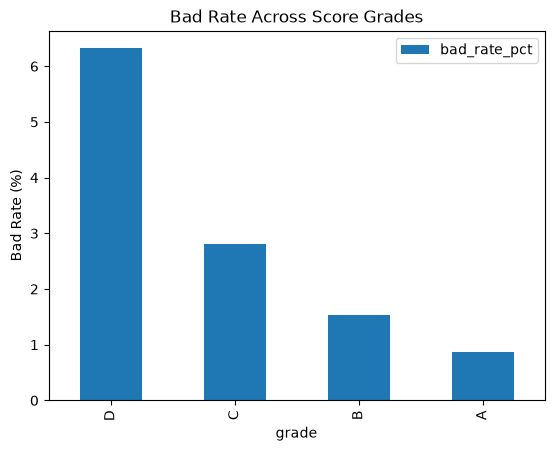

In [26]:
import matplotlib.pyplot as plt

grade_summary['bad_rate_pct'] = (
    grade_summary['bad_rate'] * 100
).round(2)

grade_summary['avg_pd_pct'] = (
    grade_summary['avg_pd'] * 100
).round(2)

grade_summary.plot(
    x='grade',
    y='bad_rate_pct',
    kind='bar'
)

plt.ylabel('Bad Rate (%)')
plt.title('Bad Rate Across Score Grades')

plt.show()

In [27]:
import numpy as np

conditions = [

    test_model['score'] >= 620,

    (test_model['score'] >= 580)
    &
    (test_model['score'] < 620),

    test_model['score'] < 580

]

choices = [

    'APPROVE',

    'REVIEW',

    'DECLINE'

]

test_model['decision'] = np.select(
    conditions,
    choices,
    default='REVIEW'
)

In [28]:
scorecard_output = test_model[[
    'TARGET',
    'PD',
    'score',
    'grade',
    'decision',
    'risk_band'
]].copy()

scorecard_output.head(2)

,TARGET,PD,score,grade,decision,risk_band
0,0,0.058497,567.293344,D,DECLINE,RB1
1,0,0.020679,598.434074,C,REVIEW,RB6


In [29]:
test_model.to_csv(

    "../Dataset/processed/scorecard_output.csv",

    index=False

)

In [30]:
def recommendation(score):

    if score >= 620:
        return "APPROVE"

    elif score >= 580:
        return "REVIEW"

    else:
        return "DECLINE"


scorecard_output['recommendation'] = (
    scorecard_output['score']
    .apply(recommendation)
)

scorecard_output.to_csv(
    "../Dataset/processed/scorecard_output.csv",
    index=False
)

In [31]:
grade_summary.to_csv(
    "../Reports/grade_summary.csv",
    index=False
)

In [32]:
band_perf.to_csv(
    "../Reports/risk_band_summary.csv"
)

In [33]:
approval_summary = []

for cutoff in [580, 620]:

    approval_rate = (
        test_model['score'] >= cutoff
    ).mean()

    bad_rate = (
        test_model[
            test_model['score'] >= cutoff
        ]['TARGET']
        .mean()
    )

    approval_summary.append({
        'cutoff': cutoff,
        'approval_rate': approval_rate,
        'bad_rate': bad_rate
    })

approval_summary = pd.DataFrame(
    approval_summary
)

approval_summary.to_csv(
    "../Reports/approval_strategy.csv",
    index=False
)

In [34]:
score_summary = (
    test_model['score']
    .describe()
    .to_frame()
)

score_summary.to_csv(
    "../Reports/score_summary.csv"
)

In [35]:
import pandas as pd

final_metrics = pd.DataFrame({

    'Metric': [

        'Train_AUC',
        'Test_AUC',

        'Train_Gini',
        'Test_Gini',

        'KS',

        'Portfolio_Bad_Rate',

        'Min_Score',
        'Max_Score',

        'Lift'

    ],

    'Value': [

        0.7141,
        0.7034,

        0.4282,
        0.4067,

        0.2900,

        0.0291,

        509.14,
        678.14,

        9.50

    ]

})

final_metrics.to_csv(
    "../Reports/final_metrics.csv",
    index=False
)

## Scorecard Results

The final PD model was transformed into a credit scorecard using standard odds-to-score scaling methodology.

Key outcomes:

- Base Score = 600
- PDO = 20
- Odds = 50:1
- Test AUC = 0.703
- Test Gini = 40.7%
- KS Statistic = 29%

Applicants were segmented into risk bands and grades based on their score distribution.

The scorecard demonstrated effective rank ordering, with observed bad rates increasing consistently across risk segments, supporting its use for credit decisioning and portfolio risk management.

## Credit Policy Simulation

Based on score distribution and observed default rates, applicants were segmented into underwriting decision bands.

| Score Range | Decision Strategy |
|-------------|------------------|
| ≥ 620 | Auto Approve |
| 580 – 619 | Manual Underwriting Review |
| < 580 | Decline / Enhanced Risk Review |

The proposed strategy enables risk-based decisioning by automatically approving low-risk applicants, routing borderline cases for analyst review, and restricting exposure to high-risk borrowers.

The highest-risk segment exhibited a bad rate exceeding 9%, compared with approximately 1% in the lowest-risk segment, demonstrating strong discriminatory power and effective borrower ranking.

In [36]:
df = pd.read_csv("../Reports/risk_band_summary.csv")
df.shape

(10, 2)

In [37]:
df

,score,TARGET
0,"(509.136, 568.398]",0.091200
1,"(568.398, 576.771]",0.045139
2,"(576.771, 584.037]",0.036577
3,"(584.037, 588.336]",0.030186
4,"(588.336, 594.653]",0.027361
5,"(594.653, 602.043]",0.021296
6,"(602.043, 607.171]",0.015060
7,"(607.171, 618.072]",0.014484
8,"(618.072, 625.205]",0.007583
9,"(625.205, 678.138]",0.010393


In [38]:
# Copy dataframe
risk_band_df = df.copy()

# Rename column
risk_band_df = risk_band_df.rename(columns={"TARGET": "Expected Bad Rate"})

# Extract Min and Max Score
risk_band_df["Min Score"] = (
    risk_band_df["score"]
    .str.extract(r"\(([\d\.]+),")[0]
    .astype(float)
    .round()
    .astype(int)
)

risk_band_df["Max Score"] = (
    risk_band_df["score"]
    .str.extract(r",\s*([\d\.]+)\]")[0]
    .astype(float)
    .round()
    .astype(int)
)

# Assign Risk Bands (first row = RB10, last row = RB1)
n = len(risk_band_df)
risk_band_df["Risk Band"] = [f"RB{i}" for i in range(n, 0, -1)]

# Convert bad rate to %
risk_band_df["Expected Bad Rate"] = (
    risk_band_df["Expected Bad Rate"] * 100
).map("{:.2f}%".format)

# Final output
risk_band_df = risk_band_df[
    ["Risk Band", "Min Score", "Max Score", "Expected Bad Rate"]
]

risk_band_df

,Risk Band,Min Score,Max Score,Expected Bad Rate
0,RB10,509,568,9.12%
1,RB9,568,577,4.51%
2,RB8,577,584,3.66%
3,RB7,584,588,3.02%
4,RB6,588,595,2.74%
5,RB5,595,602,2.13%
6,RB4,602,607,1.51%
7,RB3,607,618,1.45%
8,RB2,618,625,0.76%
9,RB1,625,678,1.04%


In [39]:
risk_band_df.to_csv(
    "../Reports/risk_band_lookup.csv",
    index=False
)